In [103]:
import sys
sys.path.append("/global/homes/z/zzhang13/DESI")
from setup import *

from tools.notebook_setup import *
from tools.projection_functions import *
from richness_relation.richness_trend_analysis import *

In [104]:
bgs_matched, zbin, lmda_bins, z_bins = prepare_default_richness_inputs()

binBoundaries = zbin.bin_boundaries
binCent = zbin.bin_centers
bin_width = zbin.bin_widths
micro_bin = zbin.micro_bin_boundaries
binCent_micro = zbin.micro_bin_centers

## Running the analysis

100%|██████████| 6000/6000 [00:26<00:00, 224.35it/s]


,z_low,z_high,model,alpha,beta,log_sigma_int,n,k,chi2,dof,...,residual_std_dex,residual_slope_vs_log_lambda,residual_intercept,max_log_likelihood,beta_low,beta_high,x_break,delta_aic,delta_bic,delta_chi2
0,0.1,0.3,loglinear,1.476675,0.221816,-1.209741,3034.0,3.0,3036.986103,3031.0,...,0.309529,0.000442,-0.000079,-746.581165,NaN,NaN,NaN,NaN,NaN,NaN
1,0.1,0.3,broken_loglinear,1.476754,NaN,-1.211214,3034.0,5.0,3036.789127,3029.0,...,0.309315,-0.001021,-0.000299,-744.364831,0.249443,-0.862634,1.959692,NaN,NaN,NaN
2,0.1,0.3,delta_broken_minus_loglinear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.432669,11.602605,-0.196976
3,0.3,0.4,loglinear,1.078764,0.126683,-1.686438,2838.0,3.0,2840.052285,2835.0,...,0.202083,-0.000855,0.000223,511.733539,NaN,NaN,NaN,NaN,NaN,NaN
4,0.3,0.4,broken_loglinear,0.995043,NaN,-1.695064,2838.0,5.0,2842.980083,2833.0,...,0.201792,-0.002619,0.000738,515.714749,-0.607952,0.157081,1.362821,NaN,NaN,NaN
5,0.3,0.4,delta_broken_minus_loglinear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.962420,7.939290,2.927798


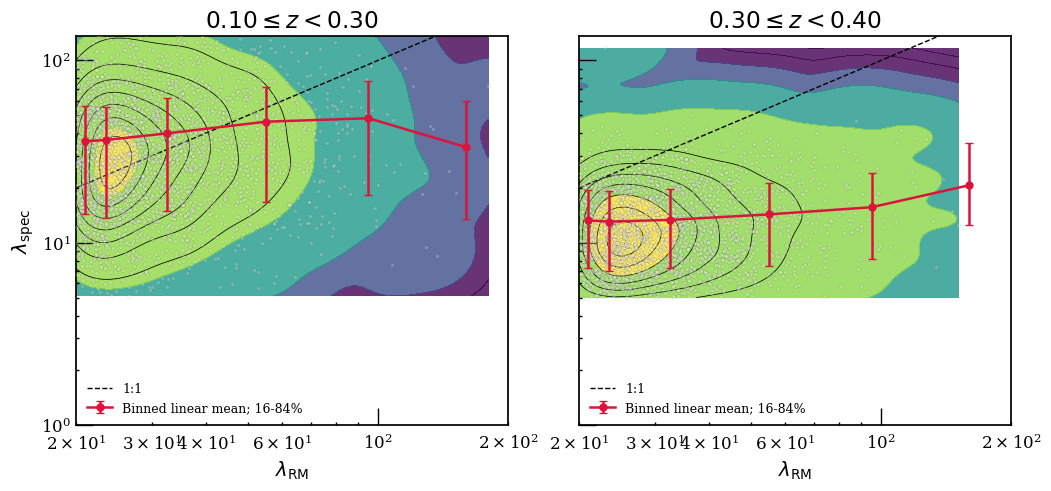

In [11]:
analysis = make_analysis_table(
    rm_df,
    lambda_rm_col="LAMBDA",       # or "lambda_tot"
    lambda_spec_col="lambda_true",
    z_col="Z_SPEC_x",
    min_lambda_rm=20,
    min_lambda_spec=5,
)

lambda_bins =  np.asarray([20,22,25,40,70,120,200])
z_bins = np.array([0.1, 0.3, 0.4])

binned = bin_lambda_z(analysis, lambda_bins, z_bins)
fig = plot_kde_binned_trends(analysis, binned, lambda_bins, z_bins)

fits = fit_models_by_redshift_bin(
    analysis,
    z_bins=z_bins,
    fit_to="individual",
    binned=binned,
    nwalkers=64,
    nsteps=6000,
    burn=1500,
)

summary = summarize_fit_results(fits)
summary


In [ ]:
## Plotting the richnesss relations

In [46]:

table['LAMBDA']
redmapper_col = 'LAMBDA'
np.asarray(table[redmapper_col]) > 20

for lo, hi in zip(redmapper_bins[:-1], redmapper_bins[1:]):
    np.asarray(table[redmapper_col])

print(np.asarray(table[redmapper_col]) > 20)

mask = (np.asarray(table[redmapper_col]) >= 20) & (np.asarray(table[redmapper_col]) <= 28)

[ True  True  True ...  True  True  True]


In [52]:
#binGap = 1e-5
wide_bin_1 = np.linspace(-0.1,-0.005,21, endpoint=False)
small_bin = np.linspace(-0.005,0.005,21, endpoint=False)
micro_bin = np.linspace(-0.005,0.005,31)
wide_bin_2 = np.linspace(0.005,0.1,21, endpoint=False)


binBoundaries = np.hstack((wide_bin_1, small_bin))
binBoundaries = np.hstack((binBoundaries, wide_bin_2))
binCent = np.asarray([(binBoundaries[i] + binBoundaries[i+1])/2 for i in range(len(binBoundaries)-1)])
binCent_micro = np.asarray([(micro_bin[i] + micro_bin[i+1])/2 for i in range(len(micro_bin)-1)])
binWidths = np.asarray([binBoundaries[i+1]-binBoundaries[i] for i in range(len(binBoundaries[:-1]))])

## None overlapping bins
assert len(set(binCent)) == len(binCent), "Overlapping bins"
assert len(set(binBoundaries)) == len(binBoundaries), "Overlapping bins"

def bin_centers(bin_edges):
    bin_edges = np.asarray(bin_edges)
    return 0.5 * (bin_edges[:-1] + bin_edges[1:])


def bin_widths(bin_edges):
    bin_edges = np.asarray(bin_edges)
    return np.diff(bin_edges)

#bin_centers = bin_centers(bin_edges)
#bin_widths = bin_widths(bin_edges)

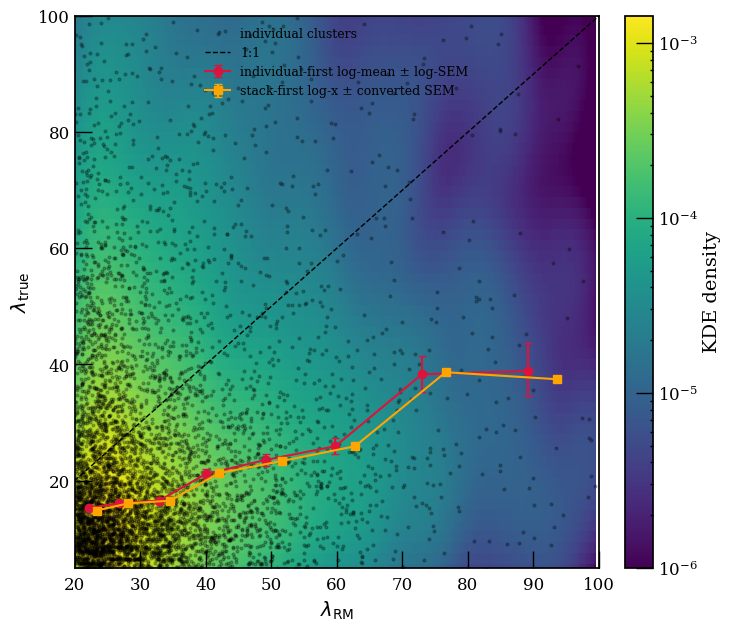

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import gaussian_kde
from astropy.table import unique

table = bgs_matched
redmapper_col = "LAMBDA"
id_col = "ID"

redmapper_bins = np.logspace(np.log10(20), np.log10(100), 9)
redmapper_values = np.asarray(table[redmapper_col], dtype=float)

logmean_lambda_rm = []
logmean_lambda_spec = []
logmean_lambda_spec_err_low = []
logmean_lambda_spec_err_high = []

stack_logmean_lambda_rm = []
stack_logmean_lambda_spec = []
stack_logmean_err_low = []
stack_logmean_err_high = []

n_clusters = []

scatter_lambda_rm = []
scatter_lambda_spec = []

for lo, hi in zip(redmapper_bins[:-1], redmapper_bins[1:]):
    mask = (redmapper_values >= lo) & (redmapper_values < hi)
    sub = table[mask]

    if len(sub) == 0:
        logmean_lambda_rm.append(np.nan)
        logmean_lambda_spec.append(np.nan)
        logmean_lambda_spec_err_low.append(np.nan)
        logmean_lambda_spec_err_high.append(np.nan)

        stack_logmean_lambda_rm.append(np.nan)
        stack_logmean_lambda_spec.append(np.nan)
        stack_logmean_err_low.append(np.nan)
        stack_logmean_err_high.append(np.nan)

        n_clusters.append(0)
        continue

    ids = np.unique(np.asarray(sub[id_col]))
    n_clusters.append(len(ids))

    id_ind, _, lambda_true_ind = calc_specRichness_individual(
        bin_edges,
        bin_centers(bin_edges),
        sub,
    )

    _, lambda_true_stack, _ = calc_specRichness_stacked(
        bin_edges,
        bin_centers(bin_edges),
        sub,
    )

    id_ind = np.asarray(id_ind)
    lambda_true_ind = np.asarray(lambda_true_ind, dtype=float)

    finite = np.isfinite(lambda_true_ind) & (lambda_true_ind > 0)
    id_ind = id_ind[finite]
    lambda_true_ind = lambda_true_ind[finite]

    sub_unique = unique(sub, keys=id_col)
    id_to_lambda_rm = {
        row[id_col]: float(row[redmapper_col])
        for row in sub_unique
    }

    lambda_rm_ind = []
    lambda_spec_ind = []

    for cid, lam_spec in zip(id_ind, lambda_true_ind):
        if cid in id_to_lambda_rm:
            lam_rm = id_to_lambda_rm[cid]
            if np.isfinite(lam_rm) and lam_rm > 0 and np.isfinite(lam_spec) and lam_spec > 0:
                lambda_rm_ind.append(lam_rm)
                lambda_spec_ind.append(lam_spec)
                scatter_lambda_rm.append(lam_rm)
                scatter_lambda_spec.append(lam_spec)

    lambda_rm_ind = np.asarray(lambda_rm_ind, dtype=float)
    lambda_spec_ind = np.asarray(lambda_spec_ind, dtype=float)

    if len(lambda_spec_ind) > 1:
        log_rm = np.log10(lambda_rm_ind)
        log_spec = np.log10(lambda_spec_ind)

        mean_log_rm = np.nanmean(log_rm)
        mean_log_spec = np.nanmean(log_spec)
        sem_log_spec = np.nanstd(log_spec, ddof=1) / np.sqrt(len(log_spec))

        y_center = 10**mean_log_spec
        y_low = 10**(mean_log_spec - sem_log_spec)
        y_high = 10**(mean_log_spec + sem_log_spec)

        logmean_lambda_rm.append(10**mean_log_rm)
        logmean_lambda_spec.append(y_center)
        logmean_lambda_spec_err_low.append(y_center - y_low)
        logmean_lambda_spec_err_high.append(y_high - y_center)

    else:
        logmean_lambda_rm.append(np.nan)
        logmean_lambda_spec.append(np.nan)
        logmean_lambda_spec_err_low.append(np.nan)
        logmean_lambda_spec_err_high.append(np.nan)

    if (
        len(lambda_rm_ind) > 1
        and len(lambda_spec_ind) > 1
        and np.isfinite(lambda_true_stack)
        and lambda_true_stack > 0
    ):
        mean_log_rm_stack = np.nanmean(np.log10(lambda_rm_ind))
    
        log_spec_ind = np.log10(lambda_spec_ind)
        sigma_dex = np.nanstd(log_spec_ind, ddof=1)

        ## This gives the log-mean
        inferred_stack_mean_log_spec = (
            np.log10(lambda_true_stack)
            - 0.5 * np.log(10) * sigma_dex**2
        ) 
    
        y_center_stack = 10**inferred_stack_mean_log_spec
    
        # Original stack error, converted into log-space around lambda_true_stack.
        stack_sem_linear = np.sqrt(lambda_true_stack / len(ids))
        stack_sem_log = stack_sem_linear / (lambda_true_stack * np.log(10))
    
        y_low_stack = 10**(inferred_stack_mean_log_spec - stack_sem_log)
        y_high_stack = 10**(inferred_stack_mean_log_spec + stack_sem_log)
    
        stack_logmean_lambda_rm.append(10**mean_log_rm_stack)
        stack_logmean_lambda_spec.append(y_center_stack)
        stack_logmean_err_low.append(y_center_stack - y_low_stack)
        stack_logmean_err_high.append(y_high_stack - y_center_stack)
    
    else:
        stack_logmean_lambda_rm.append(np.nan)
        stack_logmean_lambda_spec.append(np.nan)
        stack_logmean_err_low.append(np.nan)
        stack_logmean_err_high.append(np.nan)

logmean_lambda_rm = np.asarray(logmean_lambda_rm, dtype=float)
logmean_lambda_spec = np.asarray(logmean_lambda_spec, dtype=float)
logmean_lambda_spec_err_low = np.asarray(logmean_lambda_spec_err_low, dtype=float)
logmean_lambda_spec_err_high = np.asarray(logmean_lambda_spec_err_high, dtype=float)

stack_logmean_lambda_rm = np.asarray(stack_logmean_lambda_rm, dtype=float)
stack_logmean_lambda_spec = np.asarray(stack_logmean_lambda_spec, dtype=float)
stack_logmean_err_low = np.asarray(stack_logmean_err_low, dtype=float)
stack_logmean_err_high = np.asarray(stack_logmean_err_high, dtype=float)

lambda_rm = np.asarray(scatter_lambda_rm, dtype=float)
lambda_true_list = np.asarray(scatter_lambda_spec, dtype=float)

scatter_mask = (
    np.isfinite(lambda_rm)
    & np.isfinite(lambda_true_list)
    & (lambda_rm > 0)
    & (lambda_true_list > 0)
)

lambda_rm = lambda_rm[scatter_mask]
lambda_true_list = lambda_true_list[scatter_mask]

nbins = 300
k = gaussian_kde([lambda_rm, lambda_true_list])

xi, yi = np.mgrid[
    np.min(lambda_rm):np.max(lambda_rm):nbins * 1j,
    lambda_true_list.min():lambda_true_list.max():nbins * 1j,
]

zi = k(
    np.vstack(
        [
            xi.flatten(),
            yi.flatten(),
        ]
    )
).reshape(xi.shape)

fig, ax = plt.subplots(
    1,
    figsize=(7.2, 6.2),
    sharex="all",
    sharey="all",
    constrained_layout=True,
)

pcm = ax.pcolormesh(
    xi,
    yi,
    zi,
    norm=colors.LogNorm(1e-6, zi.max()),
    cmap="viridis",
    shading="auto",
    zorder=1,
)

cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("KDE density")

ax.scatter(
    lambda_rm,
    lambda_true_list,
    s=4,
    alpha=0.25,
    color="black",
    label="individual clusters",
    zorder=2,
)

good_ind = (
    np.isfinite(logmean_lambda_rm)
    & np.isfinite(logmean_lambda_spec)
    & np.isfinite(logmean_lambda_spec_err_low)
    & np.isfinite(logmean_lambda_spec_err_high)
    & (logmean_lambda_rm > 0)
    & (logmean_lambda_spec > 0)
)

ax.errorbar(
    logmean_lambda_rm[good_ind],
    logmean_lambda_spec[good_ind],
    yerr=[
        logmean_lambda_spec_err_low[good_ind],
        logmean_lambda_spec_err_high[good_ind],
    ],
    marker="o",
    linestyle="-",
    capsize=3,
    color="crimson",
    ecolor="crimson",
    label="individual-first log-mean ± log-SEM",
    zorder=4,
)

good_stack = (
    np.isfinite(stack_logmean_lambda_rm)
    & np.isfinite(stack_logmean_lambda_spec)
    & np.isfinite(stack_logmean_err_low)
    & np.isfinite(stack_logmean_err_high)
    & (stack_logmean_lambda_rm > 0)
    & (stack_logmean_lambda_spec > 0)
)

ax.errorbar(
    stack_logmean_lambda_rm[good_stack] * 1.05,
    stack_logmean_lambda_spec[good_stack],
    yerr=[
        stack_logmean_err_low[good_stack],
        stack_logmean_err_high[good_stack],
    ],
    marker="s",
    linestyle="-",
    capsize=3,
    color="orange",
    ecolor="orange",
    label="stack-first log-x ± converted SEM",
    zorder=5,
)

xline = np.linspace(20, 100, 200)
ax.plot(
    xline,
    xline,
    color="black",
    linestyle="--",
    linewidth=1,
    label="1:1",
    zorder=6,
)

ax.set_ylabel(r"$\lambda_{\rm true}$")
ax.set_xlabel(r"$\lambda_{\rm RM}$")

ax.set_xlim([20, 100])
ax.set_ylim([5, 100])

ax.legend(frameon=False, fontsize=9)
plt.show()


## Binning
* Binning it in redMaPPer richness and redshift bins

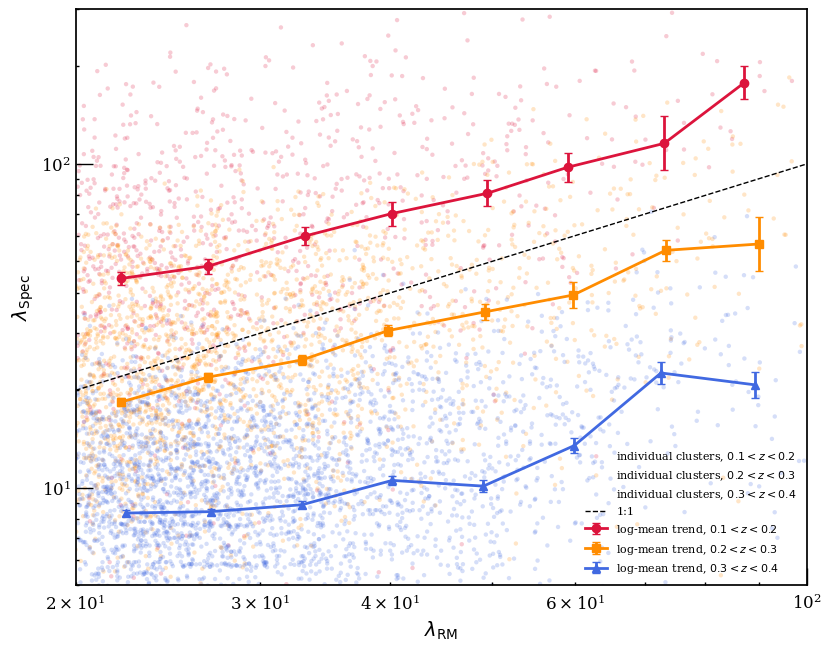

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import unique

table = bgs_matched

redmapper_col = "LAMBDA"
id_col = "ID"
z_col = "Z_SPEC_x"

z_bins = [[0.1, 0.2], [0.2, 0.3], [0.3, 0.4]]
z_colors = ["crimson", "darkorange", "royalblue"]
z_markers = ["o", "s", "^"]

rm_trend_bins = np.logspace(np.log10(20), np.log10(100), 9)

redmapper_values = np.asarray(table[redmapper_col], dtype=float)
z_values = np.asarray(table[z_col], dtype=float)

fig, ax = plt.subplots(figsize=(8.2, 6.4), constrained_layout=True)

for iz, ((zlo, zhi), color, marker) in enumerate(zip(z_bins, z_colors, z_markers)):
    zmask = (z_values >= zlo) & (z_values < zhi)
    zsub = table[zmask]
    zsub_rm_values = np.asarray(zsub[redmapper_col], dtype=float)

    all_lambda_rm = []
    all_lambda_spec = []

    ind_x = []
    ind_y = []
    ind_yerr_low = []
    ind_yerr_high = []

    for lo, hi in zip(rm_trend_bins[:-1], rm_trend_bins[1:]):
        mask = (zsub_rm_values >= lo) & (zsub_rm_values < hi)
        sub = zsub[mask]

        if len(sub) == 0:
            continue

        id_ind, _, lambda_true_ind = calc_specRichness_individual(
            bin_edges,
            bin_centers(bin_edges),
            sub,
        )

        id_ind = np.asarray(id_ind)
        lambda_true_ind = np.asarray(lambda_true_ind, dtype=float)

        finite = np.isfinite(lambda_true_ind) & (lambda_true_ind > 0)
        id_ind = id_ind[finite]
        lambda_true_ind = lambda_true_ind[finite]

        sub_unique = unique(sub, keys=id_col)
        id_to_lambda_rm = {
            row[id_col]: float(row[redmapper_col])
            for row in sub_unique
        }

        lambda_rm_ind = []
        lambda_spec_ind = []

        for cid, lam_spec in zip(id_ind, lambda_true_ind):
            if cid in id_to_lambda_rm:
                lam_rm = id_to_lambda_rm[cid]
                if np.isfinite(lam_rm) and lam_rm > 0:
                    lambda_rm_ind.append(lam_rm)
                    lambda_spec_ind.append(lam_spec)
                    all_lambda_rm.append(lam_rm)
                    all_lambda_spec.append(lam_spec)

        lambda_rm_ind = np.asarray(lambda_rm_ind, dtype=float)
        lambda_spec_ind = np.asarray(lambda_spec_ind, dtype=float)

        if len(lambda_spec_ind) <= 1:
            continue

        log_rm = np.log10(lambda_rm_ind)
        log_spec = np.log10(lambda_spec_ind)

        mean_log_rm = np.nanmean(log_rm)
        mean_log_spec = np.nanmean(log_spec)
        sem_log_spec = np.nanstd(log_spec, ddof=1) / np.sqrt(len(log_spec))

        x_ind = 10**mean_log_rm
        y_ind = 10**mean_log_spec
        y_ind_low = 10**(mean_log_spec - sem_log_spec)
        y_ind_high = 10**(mean_log_spec + sem_log_spec)

        ind_x.append(x_ind)
        ind_y.append(y_ind)
        ind_yerr_low.append(y_ind - y_ind_low)
        ind_yerr_high.append(y_ind_high - y_ind)

    all_lambda_rm = np.asarray(all_lambda_rm, dtype=float)
    all_lambda_spec = np.asarray(all_lambda_spec, dtype=float)

    finite_all = (
        np.isfinite(all_lambda_rm)
        & np.isfinite(all_lambda_spec)
        & (all_lambda_rm > 0)
        & (all_lambda_spec > 0)
    )

    all_lambda_rm = all_lambda_rm[finite_all]
    all_lambda_spec = all_lambda_spec[finite_all]

    ax.scatter(
        all_lambda_rm,
        all_lambda_spec,
        s=10,
        alpha=0.22,
        color=color,
        edgecolor="none",
        label=rf"individual clusters, ${zlo}<z<{zhi}$",
        zorder=1,
    )

    ind_x = np.asarray(ind_x, dtype=float)
    ind_y = np.asarray(ind_y, dtype=float)
    ind_yerr_low = np.asarray(ind_yerr_low, dtype=float)
    ind_yerr_high = np.asarray(ind_yerr_high, dtype=float)

    good_ind = (
        np.isfinite(ind_x)
        & np.isfinite(ind_y)
        & np.isfinite(ind_yerr_low)
        & np.isfinite(ind_yerr_high)
        & (ind_x > 0)
        & (ind_y > 0)
    )

    ax.errorbar(
        ind_x[good_ind],
        ind_y[good_ind],
        yerr=[
            ind_yerr_low[good_ind],
            ind_yerr_high[good_ind],
        ],
        marker=marker,
        linestyle="-",
        capsize=3,
        color=color,
        ecolor=color,
        lw=2,
        ms=6,
        label=rf"log-mean trend, ${zlo}<z<{zhi}$",
        zorder=4 + iz,
    )

xline = np.linspace(20, 100, 200)
ax.plot(
    xline,
    xline,
    color="black",
    linestyle="--",
    linewidth=1,
    label="1:1",
    zorder=8,
)

ax.set_xlabel(r"$\lambda_{\rm RM}$")
ax.set_ylabel(r"$\lambda_{\rm Spec}$")

ax.set_xlim(20, 100)
ax.set_ylim(5, 300)

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(frameon=False, fontsize=8, ncol=1)
plt.savefig(plots_dir()+'richness_scaling_redshift_binned.jpeg')
plt.show()
